<a href="https://colab.research.google.com/github/HectorOik/UCL-Machine-Vision-Final-Lab/blob/main/Model_Training_(FINAL_SUBMISSION_DO_NOT_TOUCH).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Setting up environment. May take a couple of minutes...")
!pip uninstall -y opencv-python opencv-python-headless -q
!pip install "opencv-python-headless<4.11" "mediapipe==0.10.14" boto3 -q

Setting up environment. May take a couple of minutes...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 

## Download the data

The data for this assignment has been made available and is downloadable to disk by running the below cell.

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os

# Connect to S3 without authentication (public bucket)
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

bucket_name = 'prism-mvta'
prefix = 'training-and-validation-data/'
download_dir = './video-data'

os.makedirs(download_dir, exist_ok=True)

# List all objects in the S3 path
paginator = s3.get_paginator('list_objects_v2')
pages = paginator.paginate(Bucket=bucket_name, Prefix=prefix)

video_names = []

for page in pages:
    if 'Contents' not in page:
        print("No files found at the specified path! Go and complain to the TAs!")
        break

    for obj in page['Contents']:
        key = obj['Key']
        filename = os.path.basename(key)

        if not filename:
            continue

        video_names.append(filename)

        local_path = os.path.join(download_dir, filename)
        print(f"Downloading: {filename}")
        s3.download_file(bucket_name, key, local_path)

print("\n" + "="*50)
print("Downloaded videos:")
print("="*50)
for name in video_names:
    print(name)

print(f"\nTotal: {len(video_names)} files")

Downloading: 1_dksksjfwijf.mp4
Downloading: 2_dfsaeklnvvalkej.mp4
Downloading: 2_difficult_2.mp4
Downloading: 2_difficult_sdafkljsalkfj.mp4
Downloading: 2_dkdjwkndkfw.mp4
Downloading: 2_dkdmkejkeimdh.mp4
Downloading: 2_dkjd823kjf.mp4
Downloading: 2_dsalkfjalwkenlke.mp4
Downloading: 2_kling_20251205_Text_to_Video_On_a_sandy_4976_0.mp4
Downloading: 2_kling_20251206_Text_to_Video_Generate_a_71_1.mp4
Downloading: 2_sadfasjldkfjaseifj.mp4
Downloading: 2_sdafkjaslkclaksdjkas.mp4
Downloading: 2_sdfkjsaleijflaskdjf.mp4
Downloading: 2_sdjfhafsldkjhjk.mp4
Downloading: 2_sdkjdsflkjfwa.mp4
Downloading: 2_sdlfjlewlkjkj.mp4
Downloading: 2_sdlkjsaelijfksdjf.mp4
Downloading: 3_asldkfjalwieaskdfaskdf.mp4
Downloading: 3_dkk873lkjlksajdf.mp4
Downloading: 3_dsjlaeijlksjdfie.mp4
Downloading: 3_dsksdfjbvsdkj.mp4
Downloading: 3_dslkaldskjflakjs.mp4
Downloading: 3_ewdfkjwaeoihjlkasdjf.mp4
Downloading: 3_kling_20251205_Text_to_Video_In_a_grass_4697_0.mp4
Downloading: 3_kling_20251205_Text_to_Video_On_a_playg_5

These videos are now available in the folder "video-data". You can click on the folder icon on the left-hand-side of this screen to see the videos in a file explorer.

# Create your Datasets and Dataloaders

Some example code for approaching the first *two* TODOs is given below just to get you started. No starter code is given for the third TODO.

Note, the below code is very rough skeleton code. Make no assumptions as to the correct manner to architect your model based on the structure of this code.

Please feel free to (if not encouraged to) change every single line of the below code (change it to best suit your chosen model architecture, in the next section).

### TODO 1 (This is mostly already done for you - Please see the v1 provided below)

Each video in the folder is prefixed by a number. That number corresponds to the number of distinct pushups visible in the video. Write code to iterate over each video in the folder, and extract the corresponding target associated with the video.

### TODO 2 (This is also mostly already done for you - Please see the v1 provided below)


Divide the data into training and validation sets.

Optionally, you can also create out your own test set to assess your performance.

### TODO 3

Any preprocessing or augmentation of your data which you deem required, should (probably) go here. You are also free to include your data-augmentation code later, though doing it before creating your dataloaders is probably a good idea.

If you complete this TODO, to maintain experimental hygiene, feel free to modify the code which was provided for TODOs 1 and 2.

In [ ]:
# =========================
#
#      Data Processing
#
# =========================

# necessary imports
import os
import cv2
import random
import torch
import numpy as np
import mediapipe as mp
from tqdm import tqdm
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, ConcatDataset

class Constants:
  MAX_FRAMES = 1000     # at 30 fps this is over 30 seconds, much longer than training videos. Nevertheless, 0 padding is cheap in this model framework
  POSE_DIMS = 33 * 3    # 33 landmarks * (x,y,z) = 99 dimensions (3D pose estimation)
  BATCH_SIZE = 64
  CACHE_DIR = './pose_cache' # save .npy files for ease of access during development
  VIDEO_DIR = './video-data'

os.makedirs(Constants.CACHE_DIR, exist_ok=True)
print(f'Cache directory created at: {Constants.CACHE_DIR}')

# =====================
#   Data Augmentation
# =====================

"""
Apply data augmentation to the MediaPipe pose output directly
to avoid CPU bottlenecks from repeatedly estimating poses from
the same raw videos
"""
class PoseAugmenter:
  def __init__(self, flip_prob=0.5, noise_std=0.01, speed_range=(0.8, 1.2)):
    self.flip_prob = flip_prob
    self.noise_std = noise_std
    self.speed_range = speed_range

  def augment(self, pose_sequence):
    """
    Input: (Max_Frames, 99) numpy array
    Output: Augmented (Max_Frames, 99) numpy array
    """

    # horizonal flip
    if random.random() < self.flip_prob:
      pose_sequence = pose_sequence.copy()
      pose_sequence[:, 0::3] *= -1

    # time warping
    speed = random.uniform(*self.speed_range)
    if abs(speed - 1.0) > 0.05: # don't do if speed change is too small
      original_len = pose_sequence.shape[0]
      if original_len > 5: # dont warp tiny clips
        x_old = np.arange(original_len)
        x_new = np.arange(0, original_len, speed)
        # interpolate each channel
        new_seq = np.zeros((len(x_new), pose_sequence.shape[1]), dtype=np.float32)
        for i in range(pose_sequence.shape[1]):
          new_seq[:, i] = np.interp(x_new, x_old, pose_sequence[:, i])
        pose_sequence = new_seq

    # jitter
    noise = np.random.normal(0, self.noise_std, pose_sequence.shape)
    pose_sequence += noise

    return pose_sequence.astype(np.float32)


# =============================
#   Synthetic Data Generation
# =============================

def resample_sequence(seq, target_len):
  """Squishes/Stretches data to fit target_len"""
  if len(seq) == 0: return np.zeros((target_len, 99), dtype=np.float32)

  resampled = cv2.resize(seq, (99, target_len), interpolation=cv2.INTER_LINEAR)
  return resampled.astype(np.float32)

def perturb(seq):
  """
  Slightly modify a video chunk before stitching for more variation
  Avoid repeating data augmentor logic here, as aggressive transformations,
  like flips, can lead to unexpected jump cuts during stitching
  """
  if len(seq) < 10: return seq

  # small speedup/slowdown
  speed_factor = random.uniform(0.9, 1.1)
  new_len = int(len(seq) * speed_factor)
  seq = resample_sequence(seq, new_len)
  # add noise
  seq += np.random.normal(0, 0.005, seq.shape)
  return seq.astype(np.float32)

def calculate_elbow_angle(landmarks):
  """
  Compute average elbow angle for a single frame (flattened 99-dim)
  """
  lm = landmarks.reshape(-1,3)

  def get_angle(idx_a, idx_b, idx_c):
    a = lm[idx_a] # shoulder
    b = lm[idx_b] # elbow
    c = lm[idx_c] # wrist
    ba = a - b
    bc = c - b

    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))
    return angle

  # average angle over left and right elbow
  return (get_angle(11, 13, 15) + get_angle(12, 14, 16)) / 2.0

def get_one_rep_slice(seq, label):
  """
  Smart slicing using signal processing to dynamically find rep boundaries.
  Logic: A rep is defined as the window between two 'Tops' (maxima) of elbow angle
  centered on a 'Bottom' (minima / valley)
  Assumption: no major acceleration between consecutive reps
  """
  if label <= 1: return seq

  angles = np.array([calculate_elbow_angle(frame) for frame in seq])

  # find peaks of (-angle) to find local minima
  valleys, _ = find_peaks(-angles, prominence=15, distance=10)

  # ===========================
  #   Safety for Messy Signal
  # ===========================
  """if singal is messy resort to simple arithmetic slicing, taking the first 1 / label frames"""
  if len(valleys) < 2:
    rep_duration = seq.shape[0] // label
    rep_idx = random.randint(0, label - 1)

    start_idx = rep_idx * rep_duration
    end_idx = start_idx + rep_duration

    # add random noise to cut points such that it's not rigid
    jitter = random.randint(-5,5)
    # safely jitter to avoid indexing issues
    start  = max(0, start_idx + jitter)
    end    = min(seq.shape[0], end_idx + jitter)

    return seq[start_idx:end_idx]

  # =================
  #   Smart Slicing
  # =================

  target_idx = random.randint(0, len(valleys) - 1)
  center = valleys[target_idx]

  # dynamic start point: midpoint b/n this valley and previous one
  if target_idx > 0:
    prev_center = valleys[target_idx - 1]
    start = (prev_center + center) // 2
  else: # first rep: estimate based on symmetry assumption (distance to next valley)
    if len(valleys) > 1:
      next_center = valleys[target_idx + 1]
      half_dist = (next_center - center) // 2
      start = max(0, center - half_dist)
    else:
      start = 0

  # dynamic end point
  if target_idx < len(valleys) - 1:
    next_center = valleys[target_idx + 1]
    end = (center + next_center) // 2
  else:
    if target_idx > 0:
      prev_center = valleys[target_idx - 1]
      half_dist = (center - prev_center) // 2
      end = min(seq.shape[0], center + half_dist)
    else:
      end = seq.shape[0]

  # extract
  slice_seq = seq[start:end]

  # edge case: slice too tiny
  if slice_seq.shape[0] < 10: return seq

  return slice_seq

def generate_boomerang_sequence(base_clip, target_reps):
  """
  Input:
    base_clip: (T, 99) Tensor - A single clean rep
    target_reps: int - How many reps we want
  Output:
    stitched clip, stitching base_clip to itself in Forward then Reverse to avoid jump cuts
  This relies on the base_clips being precice.
  """
  segments = []

  base_fwd = base_clip
  # create rev clip once
  base_rev = np.flip(base_clip, axis=0)

  for i in range(target_reps):
    if i % 2 == 0:
      seg = base_fwd if i == 0 else base_fwd[1:]
    else:
      seg = base_rev[1:]
    segments.append(seg)

  full_seq = np.concatenate(segments, axis=0)
  return full_seq


def generate_synthetic_data(cache_dir):
  """Creates synthetic data for class labels 0, 1, 5, 6, 7, 8, 9, 10"""
  # even though '0' will not be in the test data, kept in for robustness
  print("Generating Synthetic Data for Missing/Low Frequency Classes (Slicing & Stitching)...")

  data_map = {i: [] for i in range(11)}
  files = [f for f in os.listdir(cache_dir) if f.endswith('.npy') and 'synthetic' not in f]

  if not files:
    print("No ingredients found! Run the boostrap step first")
    return

  #put 'real' data into data map
  for f in files:
    try:
      label = int(f.split('_')[0])
      data = np.load(os.path.join(cache_dir, f))
      if data.shape[0] > 0: data_map[label].append(data)
    except:
      continue

  block_banks = {
      1: [],
      2: data_map[2],
      3: data_map[3],
      4: data_map[4]
  }

  ATOM_LIMIT = 20
  sources_for_examples = data_map[2] + data_map[3] + data_map[4]
  random.shuffle(sources_for_examples)

  # get one rep slices from the most frequent classes (high variation in sliced clips)
  print(f"Mining single rep examples from {len(sources_for_examples)} source videos...")
  for src in sources_for_examples:
    if len(block_banks[1]) >= ATOM_LIMIT: break
    # extract label to slice correctly
    src_label = 2
    if any(np.array_equal(src, x) for x in data_map[3]): src_label = 3
    if any(np.array_equal(src, x) for x in data_map[4]): src_label = 4

    try:
      one_rep = get_one_rep_slice(src, src_label)
      # motion filter to avoid frozen clips
      movement_score = np.mean(np.std(one_rep, axis=0))
      if movement_score < 0.05:
        print(f"Skipped static clip (score: {movement_score:.4f})")
        continue
      if len(one_rep) > 10:
        block_banks[1].append(one_rep)
    except:
      continue

  print(f"  Harvested: 1s={len(block_banks[1])}, 2s={len(block_banks[2])}, 3s={len(block_banks[3])}, 4s={len(block_banks[4])}")

  # we create data for missing classes or classes with few clean examples
  created = {k:0 for k in [0, 1, 5, 6, 7, 8, 9, 10]}
  TARGET_COUNT = 15

  def get_target_length(label):
    # assume push ups are 1-2s -> 30-60 frames
    frames_per_rep = random.randint(35,65)
    total = (label * frames_per_rep) + 20
    return min(max(total, 60), 900)

  # class 0: noisy static frames (robustness)
  all_seqs = [s for sublist in data_map.values() for s in sublist]
  if all_seqs:
    # number of synthetic examples
    for i in range(TARGET_COUNT):
      src = random.choice(all_seqs)
      first_frame = src[0]
      duration = random.randint(100, 400)
      new_seq = np.tile(first_frame, (duration, 1))
      new_seq += np.random.normal(0, 0.003, new_seq.shape)
      np.save(os.path.join(Constants.CACHE_DIR, f"0_synthetic_{i}.npy"), new_seq.astype(np.float32))
      created[0] += 1

  target_labels = [1, 5, 6, 7, 8, 9, 10]

  for label in tqdm(target_labels, desc="Generating Classes"):
    for i in range(TARGET_COUNT):
      base_clip = None
      reps_in_block = 1

      if label % 4 == 0 and len(block_banks[4]) > 0: # 8 = 4Fwd + 4Rev
        base_clip = random.choice(block_banks[4])
        reps_in_block = 4

      elif label % 3 == 0 and len(block_banks[3]) > 0: # 6 = 3Fwd + 3Rev, 9 = 3Fwd + 3Rev + 3Fwd
        base_clip = random.choice(block_banks[3])
        reps_in_block = 3

      elif label % 2 == 0 and len(block_banks[2]) > 0: # 10s (as 6s and 8s are already captured earlier)
        base_clip = random.choice(block_banks[2])
        reps_in_block = 2

      else: # 1s, 5s, 7s
        if len(block_banks[1]) > 0:
          base_clip = random.choice(block_banks[1])
          reps_in_block = 1
        else:
          continue

      base_clip = perturb(base_clip)
      # how many times is the clip stitched w/ itself
      loops_needed = label // reps_in_block

      full_seq = generate_boomerang_sequence(perturb(base_clip), target_reps=loops_needed)

      target_len = get_target_length(label)
      final_new_seq = resample_sequence(full_seq, target_len)

      save_path = os.path.join(Constants.CACHE_DIR, f"{label}_synthetic_{i}.npy")
      np.save(save_path, final_new_seq.astype(np.float32))
      created[label] += 1

  print(f"Generation Complete: {created}")

# =================
#   Dataset Class
# =================

class PoseVideoDataset(Dataset): # used to be named VideoDataset
    """Dataset for loading videos from a folder. Labels from filename prefix."""
    def __init__(self, mode='cache', video_dir=Constants.VIDEO_DIR, cache_dir=Constants.CACHE_DIR, augment=False, max_frames=Constants.MAX_FRAMES):
        self.mode = mode
        self.cache_dir = cache_dir
        self.video_dir = video_dir
        self.max_frames = max_frames
        self.augment = augment
        self.augmenter = PoseAugmenter() if augment else None

        if self.mode == 'bootstrap':
          os.makedirs(self.cache_dir, exist_ok=True)
          self.video_files = sorted([f for f in os.listdir(video_dir) if f.endswith(('.mp4', '.avi', '.mov'))])
          # initialize mp pose only if we are actually processing raw videos
          self.mp_pose = mp.solutions.pose
          self.pose_model = self.mp_pose.Pose(
            static_image_mode=False,
            model_complexity=0, # 0=Lite (Fast)
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
          )
        else:
          self.video_files = sorted([f for f in os.listdir(cache_dir) if f.endswith('.npy')])

        # parse labels from file names
        self.labels = [
            int(f.split('_')[0]) for f in self.video_files
        ]


    def __len__(self):
        return len(self.video_files)

    def _normalize_landmarks(self, landmarks):
        """
        Input: list of 33 landmakrs objects
        Output: Normalized 99-dim vector (flattened)
        Logic: Center the hip at (0,0,0) and scale torso to unt length
        """
        # convert to numpy (33,3)
        coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])

        # center at hip: MediaPipe: 23=Left Hip, 24=Right Hip
        mid_hip = (coords[23] + coords[24]) / 2
        coords = coords - mid_hip # shift all points so hip is origin

        # scale by torso size: MediaPipe: 11=Left Shoulder, 12=Right Shoulder
        mid_shoulder = (coords[11] + coords[12]) / 2
        torso_size = np.linalg.norm(mid_shoulder - mid_hip) # euclidean distance

        if torso_size > 1e-6: coords = coords / torso_size

        # flatten and return
        return coords.flatten().astype(np.float32)

    def _process_video(self, video_path):
      """Extracts pose sequence from video. Returns (T, 99) array."""
      cap = cv2.VideoCapture(video_path)
      frames = []

      while cap.isOpened():
        ret, frame = cap.read()
        if not ret or len(frames) >= self.max_frames: break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.pose_model.process(frame_rgb)

        if results.pose_landmarks:
          landmarks = self._normalize_landmarks(results.pose_landmarks.landmark)
          frames.append(landmarks)
        else:
          frames.append(np.zeros(Constants.POSE_DIMS, dtype=np.float32))

      cap.release()

      if len(frames) < 0:
        return np.zeros((1, Constants.POSE_DIMS), dtype=np.float32)

      return np.array(frames)


    def __getitem__(self, idx):
      """
      Get video given idx
      Input: self, idx
      Output: padded pose video sequence, label, original video length
      """
      label = self.labels[idx]
      filename = self.video_files[idx]

      # during development used local cache to avoid constantly bootstrapping
      if self.mode == 'bootstrap':
        cache_path = os.path.join(self.cache_dir, filename + '.npy')
        if not os.path.exists(cache_path):
          pose_sequence = self._process_video(os.path.join(self.video_dir, filename))
          np.save(cache_path, pose_sequence)
        else:
          pose_sequence = np.load(cache_path)
      else: # cache mode: read npy directly (fast)
        try:
          pose_sequence = np.load(os.path.join(self.cache_dir, filename))
        except:
          # if cache is corrupted, re-process
          pose_sequence = np.zeros((self.max_frames, 99), dtype=np.float32)

      # augment datapoint if data augmentation is on
      if self.augment and self.augmenter:
        pose_sequence = self.augmenter.augment(pose_sequence)

      # =================
      #   Padding Logic
      # =================

      # get actual video length for cropping padding later
      actual_length = pose_sequence.shape[0]
      # copy actual data in padded buffer
      # if video was shorter, append zeros
      # if video was longer (handled in _process_video) fits perfectly
      limit = min(actual_length, self.max_frames)
      # pad video (for batching on GPU)
      padded_sequence = np.zeros((self.max_frames, Constants.POSE_DIMS), dtype=np.float32)
      padded_sequence[:limit] = pose_sequence[:limit]

      # return frames, label
      return (
          torch.tensor(padded_sequence),
          torch.tensor(label, dtype=torch.long),
          torch.tensor(limit, dtype=torch.long) # passing actual_length into model for later cropping
      )

# ========================
#   DataLoader Functions
# ========================

def get_dataloaders(video_dir=Constants.VIDEO_DIR, batch_size=Constants.BATCH_SIZE, val_split=0.2, expand_factor=5):
    """Create train and validation dataloaders."""

    # ======================================
    #   Split to Test and Validations Sets
    # ======================================

    base_dataset = PoseVideoDataset(mode='cache', augment=False)
    all_labels = [label for _, label, _ in base_dataset]

    train_indices, val_indices = train_test_split(
        list(range(len(base_dataset))),
        test_size=val_split,
        random_state=0,
        stratify=all_labels # such that all labels are present in the validation set
    )

    # data leakage as this loads all .npy files including synthetic data
    # this is intentional because some clases don't have data examples
    # however note that these classes are validating against synthetic data
    # and validation error results must be taken with a grain of salt
    val_dataset   = torch.utils.data.Subset(base_dataset, val_indices)

    train_subsets = [torch.utils.data.Subset(base_dataset, train_indices)]

    # =====================
    #   Data Augmentation
    # =====================
    for _ in range(expand_factor):
      train_subsets.append(torch.utils.data.Subset(
          PoseVideoDataset(mode='cache', augment=True),
          train_indices
      ))

    full_train_dataset = ConcatDataset(train_subsets)

    # ====================
    #   Weighted Sampler
    # ====================
    '''Deal with class imbalance - more relevant before augmentation but kept due to small dataset size'''
    val_size   = int(len(val_dataset))
    train_size = int(len(full_train_dataset))

    # get_dataloaders is called after bootstrap and synthetic data generation
    # pulling data from the cache and so sees synethetic data too
    train_labels = [base_dataset.labels[i] for i in train_indices]
    counts = np.bincount(train_labels, minlength=11)
    print(f'Train Class Counts: {counts}')

    weights = []
    for count in counts:
      weights.append(1.0 / count if count > 0 else 1.0) # don't rescale missing data weights

    weight_map = {label: weights[label] for label in range(len(weights))}

    base_sample_weights = [weight_map[label] for label in train_labels]
    full_sample_weights = base_sample_weights * (1 + expand_factor)

    sampler_weights = torch.DoubleTensor(full_sample_weights)
    sampler = WeightedRandomSampler(sampler_weights, num_samples=len(sampler_weights), replacement=True)

    # ==================
    #  Get DataLoaders
    # ==================

    train_loader = DataLoader(full_train_dataset, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_dataset, batch_size=val_size, shuffle=False)

    print(f"Train: {len(full_train_dataset)} videos, Val: {len(val_dataset)} videos")

    return train_loader, val_loader



"""Run above logic and get data"""

print(">>> Step 1: Bootstrapping Real Videos... takes around 10 minutes...")
bootstrap_dataset = PoseVideoDataset(mode='bootstrap')
for _ in tqdm(DataLoader(bootstrap_dataset, batch_size=1, shuffle=False), desc="Processing Videos"):
  pass

print("\n>>> Step 2: Generating Synthetic Data...")
generate_synthetic_data(cache_dir=Constants.CACHE_DIR)

print("\n>>> Step 3: Creating Dataloaders...")
train_loader, val_loader = get_dataloaders(expand_factor=5)

print("\n>>> SANITY CHECK:")
inputs, labels, lengths = next(iter(train_loader))
print(f"Batch Shape: {inputs.shape}")
print(f"Labels Shape: {labels.shape}")
print(f"Data Mean: {inputs.mean().item():.4f}")

Cache directory created at: ./pose_cache
>>> Step 1: Bootstrapping Real Videos... takes around 10 minutes...


Processing Videos:   0%|          | 0/77 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Processing Videos: 100%|██████████| 77/77 [08:51<00:00,  6.90s/it]



>>> Step 2: Generating Synthetic Data...
Generating Synthetic Data for Missing/Low Frequency Classes (Slicing & Stitching)...
Mining single rep examples from 71 source videos...
Skipped static clip (score: 0.0378)
Skipped static clip (score: 0.0484)
Skipped static clip (score: 0.0366)
Skipped static clip (score: 0.0430)
Skipped static clip (score: 0.0361)
  Harvested: 1s=20, 2s=16, 3s=34, 4s=21


Generating Classes: 100%|██████████| 7/7 [00:00<00:00, 62.38it/s]


Generation Complete: {0: 15, 1: 15, 5: 15, 6: 15, 7: 15, 8: 15, 9: 15, 10: 15}

>>> Step 3: Creating Dataloaders...
Train Class Counts: [12 13 13 27 17 13 13 13 12 12 12]
Train: 942 videos, Val: 40 videos

>>> SANITY CHECK:
Batch Shape: torch.Size([64, 1000, 99])
Labels Shape: torch.Size([64])
Data Mean: 0.0064


# Create a Model

For this assignment, we request you use PyTorch. Below is an example of how to instantiate a very basic PyTorch model.

Note, this model below needs a _lot_ of work.

Please include your code for creating your model below.

The only constraint here is that you define a Python object which inherits from a PyTorch nn.Module object. Beyond that, please feel free to implement anything you like: Transformer, Vision Transformer, MLP, CNN, etc.

### TODO 4

Create your model.

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class PoseRepNet(nn.Module):
  def __init__(self, input_dims=99, hidden_dims=64, num_classes=11):
    super().__init__()

    # ================
    #   Pose Encoder
    # ================

    # projects 99-dim pose -> 64-dim latent feature
    # applied to every frame independently
    self.embedding = nn.Sequential(
        nn.Linear(input_dims, 128),
        nn.ReLU(),
        nn.Linear(128, hidden_dims)
    )

    # ===================================
    #   Stripe Counter (3-Layer 2D CNN)
    # ===================================

    """Takes TxT similarity matrix as input"""
    self.cnn = nn.Sequential(
        # layer 1: 16 channels out
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2), # 64x64 -> 32x32 dim

        # layer 2: 32 channels out
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2), # 32x32 -> 16x16 dim

        # layer 3: 64 channels out
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2), # 16x16 -> 8x8 dim

        # Safety layer: ensure output is 8x8
        # Doesn't do anything on correctly sized layer 3 output
        nn.AdaptiveAvgPool2d((8,8))
    )

    # ==============
    #   Classifier
    # ==============

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(8*8*64, 128), # 64 channels * 8x8 dim input
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, num_classes) # num_classes here is 11 since 0 is included but can be dynamically changed as class input
    )

  # cropping of similarity matrix is done outside this function
  def get_similarity_matrix(self, embeds):
    """
    Calculates self-similarity matrix.
    Input: (Batch, MAX_FRAMES, Hidden) -> Output: (Batch, 1, MAX_FRAMES, MAX_FRAMES)
    """
    embeds = F.normalize(embeds, p=2, dim=-1)
    sim = torch.bmm(embeds, embeds.transpose(1,2))
    return sim.unsqueeze(1) # add channel dim: (B, 1, MAX_FRAMES, MAX_FRAMES)

  def forward(self, x, actual_lengths):
      """
      x: (Batch, Max_frames, 99)
      actual_lengths: (Batch,) - True length of each video
      """
      batch_size = x.shape[0]

      # =======================
      #   Generate Embeddings
      # =======================
      # flatten batch & time for linear layer
      x_flat = x.view(-1, x.shape[-1])
      embeds_flat = self.embedding(x_flat)
      # reshape back to (B, T, 64)
      embeds = embeds_flat.view(batch_size, -1, embeds_flat.shape[-1])

      # =====================
      #   Similairty Matrix
      # =====================
      sim_matrix = self.get_similarity_matrix(embeds)

      # crop & resize (deal with variable length): makes matrix TxT
      processed_matrices = []

      for i in range(batch_size):
        length = int(actual_lengths[i].item())

        # safety check
        if length < 2: length = 2
        if length > sim_matrix.shape[2]: length = sim_matrix.shape[2]

        # remove 0 padding (matrix is now TxT)
        valid_slice = sim_matrix[i,:,:length,:length]

        # resize similarity matrix
        resized = F.interpolate(
            valid_slice.unsqueeze(0),
            size=(64,64), # target similarity matrix size
            mode='bilinear',
            align_corners=False
        )

        processed_matrices.append(resized)

      # stach back into a batch: (B, 1, 64, 64)
      cnn_input = torch.cat(processed_matrices, dim=0)

      # ================================
      #   2D Convolutions & Classifier
      # ================================

      features = self.cnn(cnn_input)
      logits = self.classifier(features)

      return logits


# Train your Model

### TODO 5

Training time! Please include your training code below.

As per above, please feel free (and encouraged) to rip out all of the below code and replace with your (much better) code.

The below should just be used as an example to get you started.

In [ ]:
def print_diagnostics(model, train_loader, val_loader, optimizer, device):
    print("\n" + "="*40)
    print("       TRAINING DIAGNOSTICS      ")
    print("="*40)

    # hardware & model
    print(f"Device:             {device}")
    print(f"Model Parameters:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    # data loaders
    # checking the loader directly ensures we see the real batch size
    print(f"Train Batch Size:   {train_loader.batch_size}")
    print(f"Val Batch Size:     {val_loader.batch_size}")
    print(f"Train Samples:      {len(train_loader.dataset)}")
    print(f"Val Samples:        {len(val_loader.dataset)}")

    # optimization
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning Rate:      {current_lr:.6f}")

    # input shape check
    try:
        sample_inputs, sample_labels, sample_lengths = next(iter(train_loader))
        print(f"Input Shape:        {list(sample_inputs.shape)}  (Batch, Frames, Features)")
        print(f"Label Shape:        {list(sample_labels.shape)}")
    except Exception as e:
        print(f"Error! Could not inspect batch: {e}")

    print("="*40 + "\n")

In [ ]:
import torch.optim as optim

# ========================
#   Model Training Logic
# ========================

def train_epoch(model, train_loader, optimizer, criterion, device):
  model.train()
  total_loss = 0
  correct = 0
  total = 0

  for inputs, labels, lengths in train_loader:
    inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)

    optimizer.zero_grad()

    # forward pass (includes original video lengths)
    output = model(inputs, lengths)
    loss = criterion(output, labels)

    # backward pass
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    pred = output.argmax(dim=1)
    correct += pred.eq(labels).sum().item()
    total += labels.size(0)

  return total_loss / len(train_loader), correct / total


def evaluate(model, test_loader, criterion, device):
  """Run evaluation on validation/test set"""
  model.eval()
  total_loss = 0
  correct = 0
  total = 0

  #in general replace target with labels (naming convention)
  with torch.no_grad():
      for inputs, labels, lengths in test_loader:
          inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)

          output = model(inputs, lengths)

          total_loss += criterion(output, labels).item()
          pred = output.argmax(dim=1)
          correct += pred.eq(labels).sum().item()
          total += labels.size(0)

  return total_loss / len(test_loader), correct / total


def train_model(epochs=5, lr=1e-3):
    """Train and return your model."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")

    model = PoseRepNet(num_classes=11).to(device) # 0 to 10 reps
    print("Instantiated model.\n")

    train_loader, val_loader = get_dataloaders(expand_factor=5)
    print("Got dataloaders.\n")

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    print_diagnostics(model, train_loader, val_loader, optimizer, device)

    print("Go time. Let the training commence.\n")

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    # Early stopping logic - if val loss hasn't improved in 15 epochs, stop
    patience = 15
    best_val_loss = float('inf')
    counter = 0

    # taken in as an arguement. default value for epochs is 5
    for epoch in range(1, epochs + 1):

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # logging
        if epoch % 10 == 0 or epoch == 1:
          print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # check for improvement (on validation set)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            counter = 0
            print(f"Saved new best model at epoch {epoch} (Val Loss: {val_loss:.4f})")
        else:
            counter += 1

        if counter >= patience:
          print(f"No improvement in {patience} epochs. Early stopping triggered!")
          break

    print(f"Restoring best model weights...")
    model.load_state_dict(torch.load('best_model.pth'))

    return model, history



In [ ]:
# setting a manual seed for reproducibility
EPOCHS = 100
LEARNING_RATE = 1e-3

torch.manual_seed(0)
model, history = train_model(epochs=EPOCHS, lr=LEARNING_RATE)

print("\nTraining Complete!")

Using device: cuda

Instantiated model.

Train Class Counts: [12 13 13 27 17 13 13 13 12 12 12]
Train: 942 videos, Val: 40 videos
Got dataloaders.


       TRAINING DIAGNOSTICS      
Device:             cuda
Model Parameters:   570,411
Train Batch Size:   64
Val Batch Size:     40
Train Samples:      942
Val Samples:        40
Learning Rate:      0.001000
Input Shape:        [64, 1000, 99]  (Batch, Frames, Features)
Label Shape:        [64]

Go time. Let the training commence.

Epoch 1/100 | Train Loss: 1.8710, Train Acc: 0.3726 | Val Loss: 2.3103, Val Acc: 0.1500
Saved new best model at epoch 1 (Val Loss: 2.3103)
Saved new best model at epoch 2 (Val Loss: 2.0146)
Saved new best model at epoch 3 (Val Loss: 0.8540)
Saved new best model at epoch 4 (Val Loss: 0.3495)
Saved new best model at epoch 6 (Val Loss: 0.2639)
Saved new best model at epoch 7 (Val Loss: 0.2366)
Epoch 10/100 | Train Loss: 0.0034, Train Acc: 1.0000 | Val Loss: 0.2672, Val Acc: 0.9750
Epoch 20/100 | Train Loss: 0.0019,

# Evaluation

## TODO 6

Include any code which you feel is useful for evaluating your model performance below.

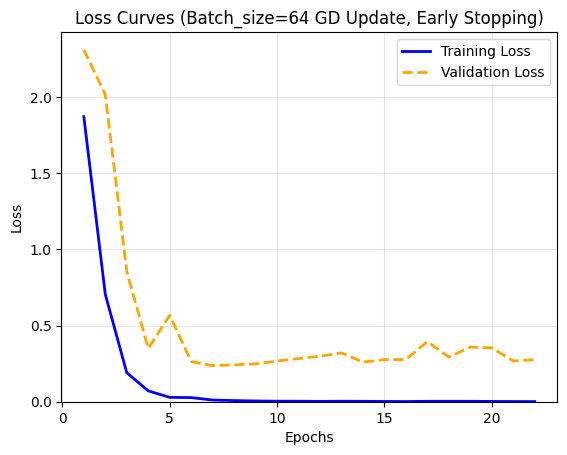

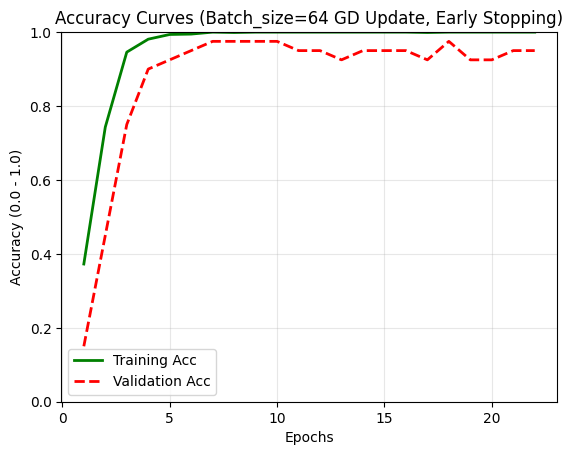

In [ ]:
# =================================
#   Plot Accuracy and Loss Curves
# =================================

import matplotlib.pyplot as plt

def plot_results(history):
  epochs = range(1, len(history['train_loss']) + 1)

  # --- PLOT 1: LOSS ---
  plt.plot(epochs, history['train_loss'], label='Training Loss', color='blue', linewidth=2)
  plt.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
  plt.title('Loss Curves (Batch_size=64 GD Update, Early Stopping)')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.ylim(bottom=0) # Loss should ideally go to 0
  plt.show()
  print() # seperate the two for seperate manual saving

  # --- PLOT 2: ACCURACY ---
  plt.plot(epochs, history['train_acc'], label='Training Acc', color='green', linewidth=2)
  plt.plot(epochs, history['val_acc'], label='Validation Acc', color='red', linestyle='--', linewidth=2)
  plt.title('Accuracy Curves (Batch_size=64 GD Update, Early Stopping)')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy (0.0 - 1.0)')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.ylim(0.0, 1.0) # Accuracy is bounded 0-1
  plt.show()

plot_results(history)

# Hugging Face

It is a requirement of this assignment that you submit your trained model to a repo on Hugging Face, and make it publicly available. Below, we provide code which should help you do this.

## TODO 7

Upload your model to HuggingFace

Install the dependencies:

In [ ]:
!pip install huggingface_hub

You'll now need to log in to Hugging Face via the command line. To do this, you'll need to generate a token on your Hugging Face account. To generate a token, run the below command, and click on the link which appears.

In [ ]:
# !hf auth login not used

The below code will only run if you have already trained a model with variable name 'model'.

The below code will take your trained model, and upload it to a *public* HuggingFace repo in your account called "mv-final-assignment".

(Note - in this example, we have set 'private=False' in the upload_to_hub method. This makes your model public).

You should double-check that your model is in fact public. To do that, you can navigate (in an incognito tab, in a browser) to https://huggingface.co/YOUR_USERNAME/YOUR_MODEL_NAME and see if that page loads. If your model is public, it will. (Simply being able to run the below code will not guarantee that your model is in fact public, because, you have now authenticated yourself with the huggingface CLI).

In [ ]:
# YOUR HUGGING FACE USERNAME BELOW
# hf_username = 'rossamurphy'
hf_username = 'hector-oikonomidis'

from huggingface_hub import login

login(write_permission=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in 'login': write_permission. Will not be supported from version '1.0'.

Fine-grained tokens added complexity to the permissions, making it irrelevant to check if a token has 'write' access.
  warnings.warn(message, FutureWarning)


In [ ]:
import torch
import torch.nn as nn
from huggingface_hub import HfApi, hf_hub_download


def save_model(model, path="model.pt"):
    """Save the model weights to a file."""
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def upload_to_hub(local_path="model.pt", repo_id=f"{hf_username}/mv-final-assignment"):
    """
    Upload model to Hugging Face Hub.

    Args:
        local_path: Path to your saved model file
        repo_id: Your repo in format "username/model-name"
    """
    api = HfApi()

    # Create the repo first (if it already exists, this will just skip)
    api.create_repo(
        repo_id=repo_id,
        repo_type="model",
        exist_ok=True,  # Don't error if it already exists
        private=False,  # Make it public so TAs can access
    )

    # Now upload the file
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo="model.pt",
        repo_id=repo_id,
        repo_type="model",
    )

    print(f"Model uploaded to https://huggingface.co/{repo_id}")


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":

    save_model(model, "mv-final-assignment.pt")

    upload_to_hub("mv-final-assignment.pt", f"{hf_username}/mv-final-assignment")


Model saved to mv-final-assignment.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  mv-final-assignment.pt      :  25%|##4       |  565kB / 2.29MB            

Model uploaded to https://huggingface.co/hector-oikonomidis/mv-final-assignment
